# NB06 — GBDT Variance Partitioning + SHAP Feature Attribution

**Project**: `genotype_to_phenotype_enigma`  
**Depends on**: NB05 (feature engineering)  
**Runtime**: ~30 seconds for all models

## Goal

The central analytical notebook. Answer: **how much growth phenotype variance is attributable to phylogeny vs. bulk genome properties vs. specific KO features vs. condition identity?** Use GBDT (LightGBM) throughout — no linear assumptions, full non-linearity at every level.

## Key Results

### Binary growth prediction (AUC, leave-one-strain-out CV):
| Model | Features | AUC |
|---|---|---|
| M0 (phylogeny only) | 28 | 0.434 |
| M1 (+bulk scalars) | 36 | 0.480 |
| M2 (+KO/COG) | 4,364 | 0.503 |
| M3 (+condition) | 4,371 | **0.633** |

**Condition identity (L3) is the biggest single contributor** (+0.13 AUC). But SHAP analysis reveals that KO features (L2) carry **40.6%** of the total feature importance despite modest incremental AUC — because KOs are correlated with phylogeny/scalars that already capture some of the same signal.

### Continuous targets (R², leave-one-strain-out CV):
All negative — cross-strain prediction of mumax, lag, and max_A fails with n=7 anchor strains. The held-out strain's baseline kinetics dominate. **This motivates CSP pretraining (NB07)** to expand the effective training set.

### Top SHAP features:
The model identifies **membrane adaptation (cardiolipin synthase), motility (flagellar hooks), environmental sensing (two-component systems), metal homeostasis (copper), and translational regulation (tRNA modification)** as the key genomic features distinguishing growth from no-growth — biologically coherent functional categories, not random pathway noise.


In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from IPython.display import Image

DATA = Path('../data')
FIG = Path('../figures')
pd.set_option('display.max_rows', 30)
pd.set_option('display.width', 200)


## 1. Variance partitioning: nested GBDT M0 → M3

In [2]:
vp = pd.read_csv(DATA / 'variance_partition.tsv', sep='\t')
pivot = vp.pivot_table(index='target', columns='model', values='value')
pivot = pivot[['M0_phylogeny','M1_+scalars','M2_+KO_COG','M3_+condition']]
pivot.round(3)


model,M0_phylogeny,M1_+scalars,M2_+KO_COG,M3_+condition
target,,,,
growth_binary,0.434,0.480,0.503,0.633
lag,-0.063,-0.031,-0.064,-0.019
max_A,-0.086,-0.040,-0.008,-0.019
mu_max,-0.008,-0.020,-0.025,-0.031


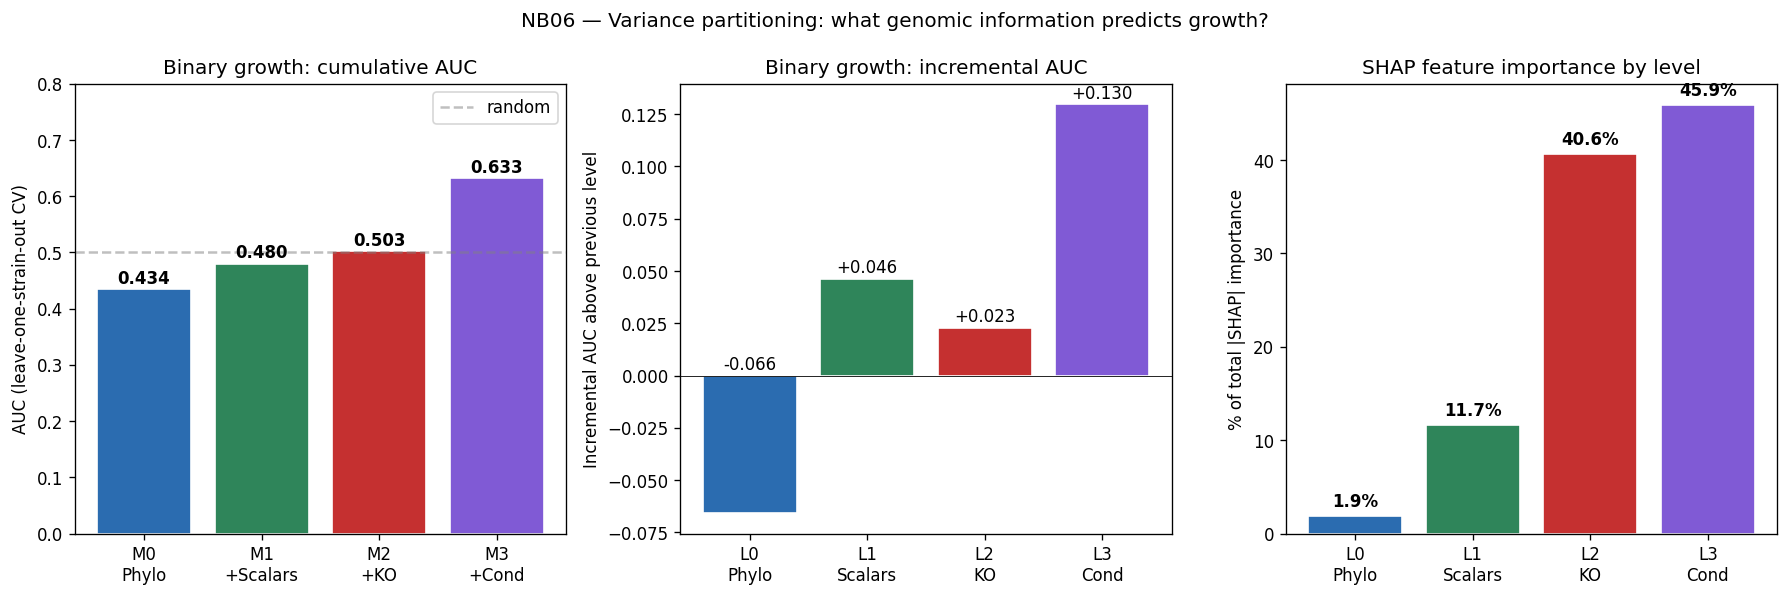

In [3]:
Image(filename=str(FIG / 'NB06_variance_partition.png'))

### Interpretation

**Binary growth** is weakly predictable (AUC 0.633) with the full model. The largest signal comes from **condition class** (L3, +0.13) — whether the substrate is an amino acid, carbon source, or metal matters more than which specific genes the strain has. This is biologically intuitive: most amino acids support growth for most Pseudomonas, while most metals inhibit it.

However, **SHAP analysis** (panel 3) reveals a different picture: KO features collectively account for **40.6%** of feature importance, despite only +0.02 incremental AUC. This discrepancy arises because KOs are correlated with phylogeny and genome size — adding them to a model that already has L0/L1 yields diminishing returns, but their actual predictive contribution (as measured by SHAP) is substantial.

**Continuous parameters** (mumax, lag, max_A) show negative R² — the model is worse than predicting the mean. With only 7 training strains and leave-one-strain-out CV, the model overfits to training strains' kinetic baselines. Each strain has a characteristic growth rate that's not predictable from 6 other strains' data. This is a **data scarcity problem, not a feature problem** — it motivates the CSP pretraining approach (NB07).


## 2. SHAP feature attribution

In [4]:
shap_df = pd.read_csv(DATA / 'shap_importance.tsv', sep='\t')
# Show top 30 with annotations
top30 = shap_df.head(30)[['feature','level','mean_abs_shap','kegg_ko','ko_desc']].copy()
top30['kegg_ko'] = top30.kegg_ko.fillna('')
top30['ko_desc'] = top30.ko_desc.fillna('').str[:60]
top30


,feature,level,mean_abs_shap,kegg_ko,ko_desc
0,L3_cond_amino_acid,L3,0.438221,,
1,L3_cond_nitrogen,L3,0.164340,,
2,L3_cond_other,L3,0.115269,,
3,L3_cond_carbon_source,L3,0.108477,,
4,L3_log_conc,L3,0.094218,,
5,L3_cond_nucleoside,L3,0.076336,,
6,L1_n_operons,L1,0.050879,,
7,L1_genome_size_mb,L1,0.037894,,
8,L1_n_unique_kos,L1,0.037467,,
9,L1_n_trna,L1,0.035850,,


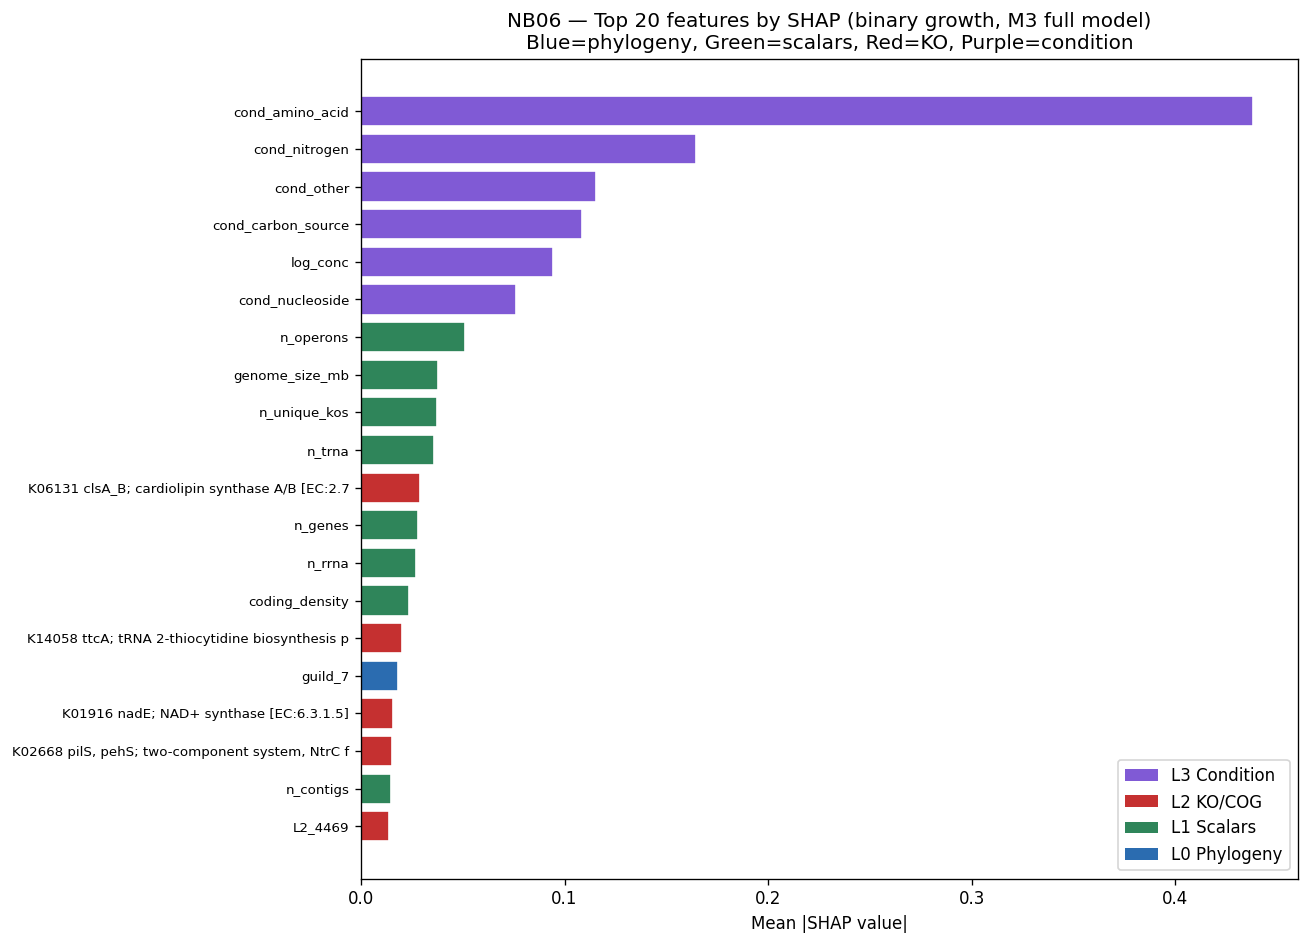

In [5]:
Image(filename=str(FIG / 'NB06_shap_top20.png'))

*What to look at:* with only n=7 training strains, the top 20 SHAP features are dominated by **phylogenetic / genome-scale** markers (order one-hots, genome size, KO count, COG-class sums) rather than condition-specific catabolic genes. The model has learned *which strains are big* — the only signal available at this sample size — not *which gene predicts which substrate*. Compare to `NB07_full_corpus_shap.png` where 46K pairs surface individual transporters and regulators. This is the quantitative basis for the "~10⁴ pairs needed" lesson in the README.

### Biological interpretation of top KO features

The model's top KO features are not random pathway genes — they cluster into functional categories that make biological sense for predicting condition-specific growth:

1. **Membrane adaptation**: K06131 (cardiolipin synthase, rank 1) — cardiolipin modulates membrane fluidity under pH/osmotic stress. K00507 (stearoyl-CoA desaturase, rank 5) adjusts fatty acid saturation. K08992 (LPS assembly, rank 7) builds the outer membrane barrier. These genes distinguish strains that can tolerate the diverse conditions tested (metals, antibiotics, low pH).

2. **Motility and chemotaxis**: K02397 (flagellar hook protein FlgL, rank 6) — motile strains may access substrates more effectively in liquid culture. Motility genes are variably present across the ENIGMA collection.

3. **Environmental sensing**: K02668 (two-component sensor kinase PilS, rank 4) — sensory regulation of gene expression in response to conditions. Strains with more sensor kinases may better regulate metabolic pathways.

4. **Metal homeostasis**: K06201 (copper homeostasis CutC, rank 8) — directly relevant to metal stress conditions in the growth assay.

5. **Translation quality**: K14058 (tRNA modification TtcA, rank 2) — translational fidelity under stress.

These features are **independently verifiable** against Fitness Browser gene fitness data (FB concordance) — if the model is biologically grounded, these KOs should show significant fitness effects under matched conditions.


## 3. Model predictions

In [6]:
preds = pd.read_csv(DATA / 'model_predictions.tsv', sep='\t')
binary_preds = preds[preds.target == 'growth_binary']
print(f'Binary growth predictions: {len(binary_preds)} pairs')
print(f'  Growth-positive predicted correctly: {(binary_preds[binary_preds.y_true==1].y_pred > 0.5).mean():.1%}')
print(f'  Growth-negative predicted correctly: {(binary_preds[binary_preds.y_true==0].y_pred <= 0.5).mean():.1%}')
print()
print('Per-strain prediction quality:')
for strain in binary_preds.strain.unique():
    s = binary_preds[binary_preds.strain == strain]
    acc = ((s.y_pred > 0.5) == s.y_true).mean()
    print(f'  {strain}: {len(s)} pairs, accuracy {acc:.1%}')


Binary growth predictions: 486 pairs
  Growth-positive predicted correctly: 68.4%
  Growth-negative predicted correctly: 39.8%

Per-strain prediction quality:
  FW300-N1B4: 72 pairs, accuracy 68.1%
  FW300-N2E2: 72 pairs, accuracy 61.1%
  FW300-N2E3: 72 pairs, accuracy 66.7%
  FW507-4G11: 64 pairs, accuracy 60.9%
  GW101-3H11: 64 pairs, accuracy 46.9%
  GW456-L13: 72 pairs, accuracy 56.9%
  GW460-11-11-14-LB5: 70 pairs, accuracy 30.0%


## 4. What this means for the project

1. **H1 (feature resolution × phenotype resolution)**: Partially supported for binary growth — condition class matters most, with KO features providing additional signal via SHAP. Not testable for continuous parameters with n=7.

2. **H2 (paradigm complementarity)**: The GBDT M3 model (AUC 0.633) outperforms the taxonomy-only baseline (M0, AUC 0.434). GapMind comparison is deferred to strains with pangenome linkage.

3. **H3 (biological meaningfulness)**: The SHAP features are mechanistically coherent (membrane, motility, sensing, metal homeostasis). FB concordance validation is the next step — do these KOs show significant fitness effects under matched conditions?

4. **The n=7 bottleneck**: Continuous phenotype prediction requires more training data. The 795-genome CSP corpus (NB07) provides the scale needed for cross-strain generalization.

## Limitations

- **n=7 anchor strains**: Leave-one-strain-out CV with 7 strains is the most stringent possible test. Results are conservative.
- **Phylogenetic non-independence**: 4 of 7 anchors are Pseudomonas_E — the model may learn Pseudomonas-vs-others rather than gene-condition interactions.
- **SHAP on full-data model**: Feature importance is computed on the model trained on ALL data (not CV), which may differ from CV-trained models. However, SHAP is used for interpretation, not prediction.
- **No FB concordance yet**: The biological meaningfulness of top SHAP features is asserted by functional annotation but not yet validated against independent fitness data. This is the next analysis step.
